# 01. OPTI-TWIST Prototype

This notebook reproduces the steady-state sparse-sensing workflow on the OPTI-TWIST temperature snapshots used by the existing RAVEN regression. The setup follows the same SSPOR idea described by Manohar et al. (2018): build a low-rank basis, choose a small number of informative sensors, and reconstruct the full field from those measurements.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysensors as ps

Matplotlib is building the font cache; this may take a moment.


In [2]:
root = Path.cwd().parents[1] / "tests" / "framework" / "PostProcessors" / "SparseSensing" / "reconstructionOptiTwist"
suffixes = ("240", "270", "300", "330")
frames = [pd.read_csv(root / f"350_{suffix}.csv") for suffix in suffixes]

T = np.stack([frame["Temperature (K)"].to_numpy() for frame in frames])
X = frames[0]["X (m)"].to_numpy()
Y = frames[0]["Y (m)"].to_numpy()

print(f"snapshot matrix shape: {T.shape}")
print(f"number of spatial points: {X.size}")

snapshot matrix shape: (4, 4051)
number of spatial points: 4051


We fit `pysensors.SSPOR` with an SVD basis of rank 4 and ask for 4 sensors. That matches the steady-state reconstruction anchor already exercised in the SparseSensing regression suite.

In [3]:
model = ps.SSPOR(basis=ps.basis.SVD(n_basis_modes=4), n_sensors=4)
model.fit(T, seed=42)
idx = model.get_selected_sensors()

sensor_table = pd.DataFrame(
    {
        "sensor_index": idx,
        "x_m": X[idx],
        "y_m": Y[idx],
    }
)
sensor_table

,sensor_index,x_m,y_m
0,3390,0.037572,-0.354206
1,3244,0.002588,-0.127089
2,247,0.037667,0.479860
3,1436,0.000149,0.051720


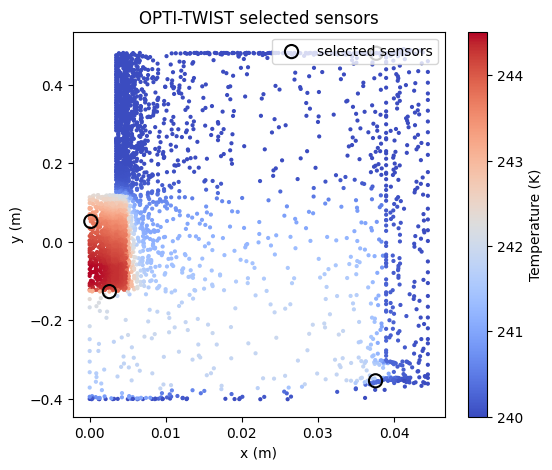

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(X, Y, c=T[0], cmap="coolwarm", s=4)
ax.scatter(X[idx], Y[idx], facecolors="none", edgecolors="black", s=90, linewidths=1.5, label="selected sensors")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("OPTI-TWIST selected sensors")
ax.legend(loc="upper right")
fig.colorbar(scatter, ax=ax, label="Temperature (K)")
plt.show()

/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set to the average of the computed prior
  warnings.warn(
/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set to the average of the computed prior
  warnings.warn(
/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set to the average of the computed prior
  warnings.warn(
/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set to the average of the computed prior
  warnings.warn(
/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set

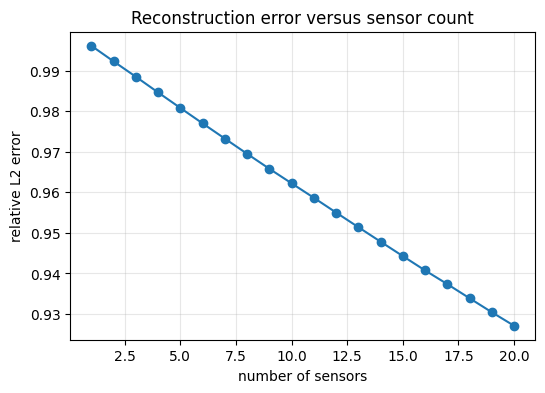

,n_sensors,relative_l2_error
0,1,0.996169
1,2,0.992317
2,3,0.988529
3,4,0.984657
4,5,0.980830
5,6,0.977028
6,7,0.973270
7,8,0.969525
8,9,0.965831
9,10,0.962240


In [5]:
errors = []
sensor_counts = range(1, 21)

for count in sensor_counts:
    fitted = ps.SSPOR(basis=ps.basis.SVD(n_basis_modes=4), n_sensors=count)
    fitted.fit(T, seed=42)
    chosen = fitted.get_selected_sensors()
    T_hat = fitted.predict(T[:, chosen])
    errors.append(np.linalg.norm(T - T_hat) / np.linalg.norm(T))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(sensor_counts), errors, "o-")
ax.set_xlabel("number of sensors")
ax.set_ylabel("relative L2 error")
ax.set_title("Reconstruction error versus sensor count")
ax.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({"n_sensors": list(sensor_counts), "relative_l2_error": errors}).head(10)

The error curve typically shows a sharp early drop and then a softer improvement as more sensors are added. The next notebook keeps the same SSPOR machinery but interprets each time step of a transient as one row in the fit matrix.